 **Навигация по уроку**

1. [Решение задач регрессии с помощью НС](https://colab.research.google.com/drive/1GbXbqPbC4A2NVJEj-5pOOySN3gyalBQN)
2. [Анализ резюме кандидатов](https://colab.research.google.com/drive/1L4pI4giYvWY3T4gfqTF5c_XFkN9k4Nfz)
3. Домашняя работа

**В домашней работе необходимо выполнить следующее задание:**

1. Используя предложенный [датасет](https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv) японских машин, обучите модель предсказывать цены на японские автомобили.
2. Создайте обучающую, тестовую и проверочную выборки.
3. Оцените качество работы созданной сети, определите средний процент ошибки на проверочной выборке.
4. В качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
5. Выполнив задание, получите 3 балла.
6. Хотите 4 балла? Добейтесь ошибки менее 10%.
7. Хотите 5 баллов? Добейтесь ошибки менее 5%.


**Примечание**. Подробную информацию о датасете можно узнать на портале соревновани [kaggle.com](https://www.kaggle.com/datasets/doaaalsenani/used-cars-dataets/data).



In [ ]:
# Для работы с массивами данных
import numpy as np

# Для работы с табличными данными
import pandas as pd

# Библиотека утилит
from keras import utils

# Для работы с моделями
from keras.models import Sequential, Model

# Слои
from keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop

# Токенизатор
from tensorflow.keras.preprocessing.text import Tokenizer

# Нормализация данных
from sklearn.preprocessing import StandardScaler

# Регулярные выражения
import re

# Для работы с графиками
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Для преобразования строки в json формат
import json

%matplotlib inline

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv

--2025-03-04 03:45:35--  https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136735 (134K) [text/csv]
Saving to: ‘japan_cars_dataset.csv.2’

japan_cars_dataset. 100%[===================>] 133.53K   231KB/s    in 0.6s    

2025-03-04 03:45:37 (231 KB/s) - ‘japan_cars_dataset.csv.2’ saved [136735/136735]



In [ ]:
import pandas as pd
cars = pd.read_csv('japan_cars_dataset.csv', sep=',')

# Удалим строки с пустыми значениями
cars = cars.dropna()

# Выводим первые 10 машин
cars.head(10)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline
5,5,190,daihatsu,mira,2004,81400,660,at,2wd,rhd,gasoline
6,8,220,nissan,march,2010,117000,1200,at,2wd,rhd,gasoline
7,9,230,volkswagen,passat,2008,127763,3190,at,4wd,rhd,gasoline
8,10,275,mazda,bongo van,2010,178218,1800,mt,2wd,rhd,gasoline
9,11,283,honda,step wgn,2005,121655,2000,at,2wd,rhd,gasoline


In [ ]:
df = cars.drop(columns=['Unnamed: 0'])

In [ ]:
# Пример данных

n = 3                                     # Индекс в таблице резюме
for i in range(len(df.values[n])):        # Вывод значения каждого столбца
    print('{:>2} {:>30}  {}'.format(i, df.columns[i], df.values[n][i]))

 0                          price  190
 1                           mark  toyota
 2                          model  avensis
 3                           year  2008
 4                        mileage  130661
 5                engine_capacity  1990
 6                   transmission  at
 7                          drive  2wd
 8                     hand_drive  rhd
 9                           fuel  gasoline


In [ ]:
df["mark"].unique()

array(['nissan', 'toyota', 'daihatsu', 'volkswagen', 'mazda', 'honda',
       'subaru', 'mercedes-benz', 'kubota', 'mitsubishi', 'suzuki', 'bmw',
       'chrysler', 'smart', 'gm', 'opel', 'isuzu', 'land rover',
       'peugeot', 'hyundai', 'kia motors', 'audi', 'citroen', 'mitsuoka',
       'volvo', 'ford', 'hino', 'jaguar'], dtype=object)

0: Премиум и высококачественные марки, известные своей надежностью и престижем.

1: Марки среднего класса, которые предлагают хорошее качество и надежность, но не являются премиум-сегментом.

2: Бюджетные и массовые марки, которые могут быть менее надежными или менее престижными, но все же предлагают приемлемое качество.

3: Марки, которые могут быть менее известными или менее популярными, часто с более низким качеством или репутацией.

In [ ]:
# Словарь с классами автомобилей
car_class = {
    'mercedes-benz': 0,
    'bmw': 0,
    'audi': 0,
    'jaguar': 0,
    'land rover': 0,
    'nissan': 1,
    'toyota': 1,
    'honda': 1,
    'subaru': 1,
    'volkswagen': 1,
    'mazda': 1,
    'hyundai': 1,
    'kia motors': 1,
    'volvo': 1,
    'daihatsu': 2,
    'mitsubishi': 2,
    'suzuki': 2,
    'peugeot': 2,
    'opel': 2,
    'ford': 2,
    'chrysler': 2,
    'gm': 2,
    'smart': 2,
    'citroen': 2,
    'mitsuoka': 2,
    'kubota': 2,
    'isuzu': 2,
    'hino': 2,
    'volkswagen': 2,
    'chrysler': 2,
    'mazda': 2,
    'ford': 2,
    'smart': 2,
    'other': 3  # Для менее известных или менее популярных марок
}

In [ ]:
import numpy as np
from tensorflow.keras import utils

def car2OHE(param):
    # Определение размерности выходного вектора, как число уникальных классов
    num_classes = len(set(car_class.values()))

    # Если не смогли распарсить, то поле не заполнено
    # Устанавливаем значение по умолчанию (последний элемент в словаре)
    if not isinstance(param, str):
        param = list(car_class.keys())[-1]

    # Поиск марки автомобиля в словаре и присвоение ей класса
    car_cls = car_class.get(param, -1)

    if car_cls == -1:
        # Если марка не найдена, присваиваем класс "other"
        car_cls = num_classes - 1

    # Возврат в виде one hot encoding-вектора
    return utils.to_categorical(car_cls, num_classes)

# Пример использования
car_name = 'nissan'
one_hot_vector = car2OHE(car_name)
print(f"One-hot encoding для '{car_name}': {one_hot_vector}")

One-hot encoding для 'nissan': [0. 1. 0. 0.]


In [ ]:
df["model"].unique()

array(['march', 'lafesta', 'avensis', 'mira', 'passat', 'bongo van',
       'step wgn', 'sambar', 'inspire', 'mercedes-benz others', 'note',
       'passo', 'impreza', 'kubota others', 'life', 'progres',
       'cube cubic', 'cube', 'a-class', 'coltplus', 'mr wagon',
       'pajero mini', 'fit', 'legacy b4', 'vitz', 'mark ii blit',
       'insight', 'move', 'tanto', 'terios kid', 'az-wagon', 'coo',
       'verisa', 'swift', 'delica d2', 'tiida', 'sienta', 'mini', 'colt',
       'platz', 'bluebird sylphy', 'eclipse', 'bb', 'moco',
       'clipper truck', 'esse', 'ek wagon', 'polo', 'x-trail',
       'atenza sport', 'ad van', 'pixis space', 'freed spike', 'stream',
       'alto', 'raum', 'wish', 'every', 'demio', 'jimny', 'premacy',
       'cr-v', 'lapin', 'delica', 'wagon r', 'lancer', 'naked', 'odyssey',
       'ractis', 'porte', 'corolla rumion', 'tiida latio', 'voxy',
       'carol', 'sunny', 'bongo truck', 'boon', 's-mx', 'pt cruiser',
       'golf', 'ad expert', 'fit hybrid', 'sere

In [ ]:
import numpy as np
from tensorflow.keras import utils

# Исходный массив
car_model = np.array(['march', 'lafesta', 'avensis', 'mira', 'passat', 'bongo van', 'step wgn', 'sambar', 'inspire',
                       'mercedes-benz others', 'note', 'passo', 'impreza', 'kubota others', 'life', 'progres',
                       'cube cubic', 'cube', 'a-class', 'coltplus', 'mr wagon', 'pajero mini', 'fit', 'legacy b4',
                       'vitz', 'mark ii blit', 'insight', 'move', 'tanto', 'terios kid', 'az-wagon', 'coo',
                       'verisa', 'swift', 'delica d2', 'tiida', 'sienta', 'mini', 'colt', 'platz',
                       'bluebird sylphy', 'eclipse', 'bb', 'moco', 'clipper truck', 'esse', 'ek wagon', 'polo',
                       'x-trail', 'atenza sport', 'ad van', 'pixis space', 'freed spike', 'stream', 'alto',
                       'raum', 'wish', 'every', 'demio', 'jimny', 'premacy', 'cr-v', 'lapin', 'delica',
                       'wagon r', 'lancer', 'naked', 'odyssey', 'ractis', 'porte', 'corolla rumion',
                       'tiida latio', 'voxy', 'carol', 'sunny', 'bongo truck', 'boon', 's-mx', 'pt cruiser',
                       'golf', 'ad expert', 'fit hybrid', 'serena', 'edix', 'move custom', 'impreza anesis',
                       'estima', 'carry truck', 'solio', 'mpv', 'vanette van', 'accord', 'tribute',
                       'pajero io', 'noah', 'vanette truck', 'delica truck', 'lancer cargo', 'atenza wagon',
                       'atenza', 'vamos', 'r2', 'fun cargo', 'airwave', 'ipsum', 'verossa', 'forfour',
                       'elgrand', 'ist', 'mirage', 'chevrolet others', 'corolla spacio', 'aerio', 'altezza',
                       'vectra', 'minicab truck', 'outback', 'mark x', 'gaia', 'alphard', 'caldina',
                       'alphard g', 'brevis', 'axela sport', 'alphard v', 'pleo', 'minicab van',
                       'nv100clipper', 'sx4', 'legacy', 'aristo', 'palette', 'wizard', 'forester',
                       'grand escudo', 'jetta', 'corolla axio', 'discovery', 'stagea', 'dion', 'mira avy',
                       'mark ii', 'corolla runx', 'hijet cargo', 'biante', 'carol eco', 'axela', 'cami',
                       'hijet truck', 'e-class', 'hr-v', 'elysion', 'crown comfort', 'canter',
                       'impreza sportswagon', 'corolla ii', '207', 'sx4 sedan', 'townace van', 'allion',
                       'passo sette', 'crown', 'civic ferio', 'fuga', 'legacy touring wagon', 'tucson',
                       'gloria hardtop', '3 series', 'x-trek', 'stella', 'bongo', 'bongo friendee',
                       'a4', 'a4 avant', 'fit shuttle', 'acty truck', 'sambar truck', 'freed', 'isis',
                       'exiga', 'skyline', 'allex', 'splash', 'titan dash', 'chaser', 'voltz', 'visto',
                       'civic hybrid', 'wingroad', 'murano', 'probox', 'c-class', 'corolla sedan',
                       'xsara picasso', 'rx-8', 'corona premio', 'comfort', 'miragino', 'new beetle',
                       'viewt', 'canter guts', 'regius wagon', 'v70', 'mira es', 'acty van', 'duet',
                       'b-class', '307', 'belta', 'otti', 'mini cooper', 'ek sport', 'escudo', 'succeed van', 'atrai wagon', 'atrai', 'z', 'mdx',
                       'galant fortis', 'terios', 'clipper van', '1 series', 'townace noah', 'premio',
                       'outlander', 'opa', 'bongo brawny truck', 'masterace surf', 'move latte',
                       'santa fe', 'terracan', 'teana', 'cima', 'auris', 'corolla fielder', 'ad',
                       'freelander', 'town box', 'probox van', 'golf variant', 'windom', 'cerato',
                       'pride', 'escape', 'landy', 'vivio', 'spade', 'clipper', 'dutro', 'elf truck',
                       'carina', 'wagon r rr', 'x-type', 'trajet', 'minica', 'c30', 'z', 'estima t'], dtype=object)

# Создаем словарь классов автомобилей
car_class = {model: index for index, model in enumerate(np.unique(car_model))}

def car2OHE(param):
    num_classes = len(car_class)

    if not isinstance(param, str):
        param = list(car_class.keys())[-1]

    car_cls = car_class.get(param, -1)

    if car_cls == -1:
        car_cls = num_classes - 1

    return utils.to_categorical(car_cls, num_classes)

car_name = 'march'
one_hot_vector = car2OHE(car_name)
print(f"One-hot encoding для '{car_name}': {one_hot_vector}")

car_name_invalid = 'nonexistent car'
one_hot_vector_invalid = car2OHE(car_name_invalid)
print(f"One-hot encoding для '{car_name_invalid}': {one_hot_vector_invalid}")

One-hot encoding для 'march': [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
One-hot encoding для 'nonexistent car': [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 

In [ ]:
df["transmission"].unique()

array(['at', 'mt', 'cvt'], dtype=object)

CVT (бесступенчатая трансмиссия) - 2

Обеспечивает плавное ускорение и экономию топлива. Хорошо подходит для городских условий.
AT (автоматическая трансмиссия) - 0

Удобна в управлении, особенно в городских условиях. Обеспечивает комфорт, но может быть менее эффективной по сравнению с CVT.
MT (механическая трансмиссия) - 1

Предоставляет водителю больше контроля и может быть более эффективной на высоких оборотах, но требует больше навыков и усилий для управления.

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# Исходный словарь
transmission = {
    'cvt': 0,
    'at': 1,
    'mt': 2,
    'other': 3,
}

def transmission2OHE(param):
    num_classes = len(transmission)

    if not isinstance(param, str):
        param = list(transmission.keys())[-1]

    transmission_cls = transmission.get(param, -1)

    if transmission_cls == -1:
        transmission_cls = num_classes - 1

    return to_categorical(transmission_cls, num_classes)

print(transmission2OHE('at'))
print(transmission2OHE('manual'))

[0. 1. 0. 0.]
[0. 0. 0. 1.]


In [ ]:
df["drive"].unique()

array(['2wd', '4wd', 'awd'], dtype=object)

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

drive = {
    'awd': 0,
    '4wd': 1,
    '2wd': 2,
    'other': 3,
}

def drive2OHE(param):
    num_classes = len(drive)

    if not isinstance(param, str):
        param = list(drive.keys())[-1]

    drive_cls = drive.get(param, -1)

    if drive_cls == -1:
        drive_cls = num_classes - 1

    return to_categorical(drive_cls, num_classes)


print(drive2OHE('4wd'))
print(drive2OHE('fwd'))

[0. 1. 0. 0.]
[0. 0. 0. 1.]


In [ ]:
df["hand_drive"].unique()

array(['rhd', 'center', 'lhd'], dtype=object)

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

steering = {
    'center': 0,
    'lhd': 1,
    'rhd': 2,
    'other': 3,
}

def steering2OHE(param):
    num_classes = len(steering)

    if not isinstance(param, str):
        param = list(steering.keys())[-1]

    steering_cls = steering.get(param, -1)

    if steering_cls == -1:
        steering_cls = num_classes - 1

    return to_categorical(steering_cls, num_classes)

print(steering2OHE('rhd'))
print(steering2OHE('unknown'))

[0. 0. 1. 0.]
[0. 0. 0. 1.]


In [ ]:
df["fuel"].unique()

array(['gasoline', 'diesel', 'hybrid', 'lpg', 'cng'], dtype=object)

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

fuel = {
    'hybrid': 0,
    'cng': 1,
    'lpg': 2,
    'diesel': 3,
    'gasoline': 4,
    'other': 5,
}
def fuel2OHE(param):
    num_classes = len(fuel)

    if not isinstance(param, str):
        param = list(fuel.keys())[-1]

    fuel_cls = fuel.get(param, -1)

    if fuel_cls == -1:
        fuel_cls = num_classes - 1

    return to_categorical(fuel_cls, num_classes)

print(fuel2OHE('gasoline'))
print(fuel2OHE('electric'))


[0. 0. 0. 0. 1. 0.]
[0. 0. 0. 0. 0. 1.]


In [ ]:
mileage_class = [0, 20000, 100000, 200000]

year_class = [2020, 2015, 2010, 2005, 2000, 1995, 1990, 1985,1980,1975]

engine_capacity_class = [0, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]


In [ ]:
import numpy as np
from tensorflow.keras import utils

def range2OHE(param, class_list):
    num_classes = len(class_list) + 1

    for i in range(num_classes - 1):
        if float(param) < class_list[i]:
            cls = i
            break
    else:
        cls = num_classes - 1

    return utils.to_categorical(cls, num_classes)

def mileage_to_OHE(mileage):
    return range2OHE(mileage, mileage_class)

def year_to_OHE(year):
    return range2OHE(year, year_class)

def engine_capacity_to_OHE(engine_capacity):
    return range2OHE(engine_capacity, engine_capacity_class)

mileage_example = 15000
year_example = 2015
engine_capacity_example = 1.8

mileage_ohe = mileage_to_OHE(mileage_example)
year_ohe = year_to_OHE(year_example)
engine_capacity_ohe = engine_capacity_to_OHE(engine_capacity_example)

print(f"One-hot encoding для пробега {mileage_example} км: {mileage_ohe}")
print(f"One-hot encoding для года выпуска {year_example}: {year_ohe}")
print(f"One-hot encoding для объема двигателя {engine_capacity_example} л: {engine_capacity_ohe}")


One-hot encoding для пробега 15000 км: [0. 1. 0. 0. 0.]
One-hot encoding для года выпуска 2015: [1. 0. 0. 0. 0. 0. 0.]
One-hot encoding для объема двигателя 1.8 л: [0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

y_scaler = StandardScaler()
df['price'] = scaler.fit_transform(df[['price']])

COL_PRICE          = df.columns.get_loc('price')
COL_MARK           = df.columns.get_loc('mark')
COL_MODEL          = df.columns.get_loc('model')
COL_YEAR           = df.columns.get_loc('year')
COL_MILEAGE        = df.columns.get_loc('mileage')
COL_ENGINE_CAPACITY = df.columns.get_loc('engine_capacity')
COL_TRANSMISSION   = df.columns.get_loc('transmission')
COL_DRIVE          = df.columns.get_loc('drive')
COL_HAND_DRIVE     = df.columns.get_loc('hand_drive')
COL_FUEL           = df.columns.get_loc('fuel')

def get_row_data(row):
    # Объединение всех входных данных в один общий вектор
    x_data = np.hstack([
                car2OHE(row[COL_MARK]),
                car2OHE(row[COL_MODEL]),
                range2OHE(row[COL_YEAR], year_class),
                range2OHE(row[COL_MILEAGE], mileage_class),
                range2OHE(row[COL_ENGINE_CAPACITY], engine_capacity_class),
                transmission2OHE(row[COL_TRANSMISSION]),
                drive2OHE(row[COL_DRIVE]),
                steering2OHE(row[COL_HAND_DRIVE]),
                fuel2OHE(row[COL_FUEL])
              ])

    # Вектор цены в нормализованном виде
    y_data = np.array([row[COL_PRICE]])

    return x_data, y_data


In [ ]:
def get_train_data(dataFrame):
    x_data = []
    y_data = []

    for row in dataFrame.values:
        x, y = get_row_data(row)
        x_data.append(x)
        y_data.append(y)

    return np.array(x_data), np.array(y_data)

x_data, y_data = get_train_data(df)

x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)


In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01), input_shape=(x_train.shape[1],)))  # Первый скрытый слой с L2-регуляризацией
model.add(Dropout(0.3))  # Слой Dropout для регуляризации
model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))  # Второй скрытый слой с L2-регуляризацией
model.add(Dropout(0.3))  # Слой Dropout для регуляризации
model.add(Dense(8, activation='relu', kernel_regularizer=l2(0.01)))  # Третий скрытый слой с L2-регуляризацией
model.add(Dense(1, activation='linear'))  # Выходной слой для регрессии

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val, y_val))

mse = model.evaluate(x_val, y_val)
print(f"Среднеквадратическая ошибка на проверочной выборке: {mse}")

test_mse = model.evaluate(x_test, y_test)
print(f"Среднеквадратическая ошибка на тестовой выборке: {test_mse}")

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.1962 - val_loss: 0.4196
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4270 - val_loss: 0.2681
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2907 - val_loss: 0.2066
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2239 - val_loss: 0.1678
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1751 - val_loss: 0.1415
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1500 - val_loss: 0.1214
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1304 - val_loss: 0.1064
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1157 - val_loss: 0.0954
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1001 - val_loss: 0.0866
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0930 - val_loss: 0.0802
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0850 - val_loss: 0.0745
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0783 - val_lo

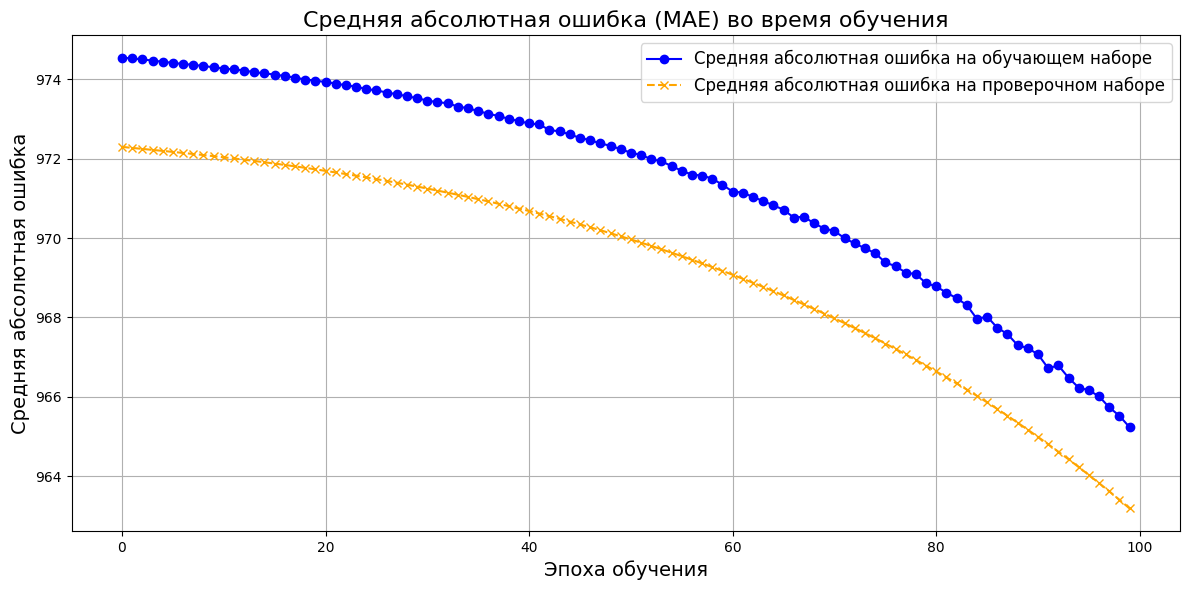

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(history.history['mae'], label='Средняя абсолютная ошибка на обучающем наборе', color='blue', linestyle='-', marker='o')

plt.plot(history.history['val_mae'], label='Средняя абсолютная ошибка на проверочном наборе', color='orange', linestyle='--', marker='x')

plt.title('Средняя абсолютная ошибка (MAE) во время обучения', fontsize=16)
plt.xlabel('Эпоха обучения', fontsize=14)
plt.ylabel('Средняя абсолютная ошибка', fontsize=14)

plt.grid(True)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Средняя абсолютная ошибка: 0.18892237948690377 

Итерация 1: Средняя абсолютная ошибка: 0.1897
Реальное значение:   0.20  Обновленное предсказанное значение:   0.64  Разница:   0.44
Реальное значение:   0.51  Обновленное предсказанное значение:   0.65  Разница:   0.15
Реальное значение:   0.43  Обновленное предсказанное значение:   0.63  Разница:   0.20
Реальное значение:   0.23  Обновленное предсказанное значение:   0.63  Разница:   0.40
Реальное значение:   0.23  Обновленное предсказанное значение:   0.68  Разница:   0.45
Реальное значение:   0.44  Обновленное предсказанное значение:   0.71  Разница:   0.27
Реальное значение:   0.75  Обновленное предсказанное значение:   0.67  Разница:   0.08
Реальное значение:   0.31  Обновленное предсказанное значение:   0.65  Разница:   0.34
Реальное значение:   0.68  Обновленное предсказанное значение:   0.68  Разница:   0.00
Реальное значение:   0.67  Обновленное предсказанное значение:   0.68  Разница:   

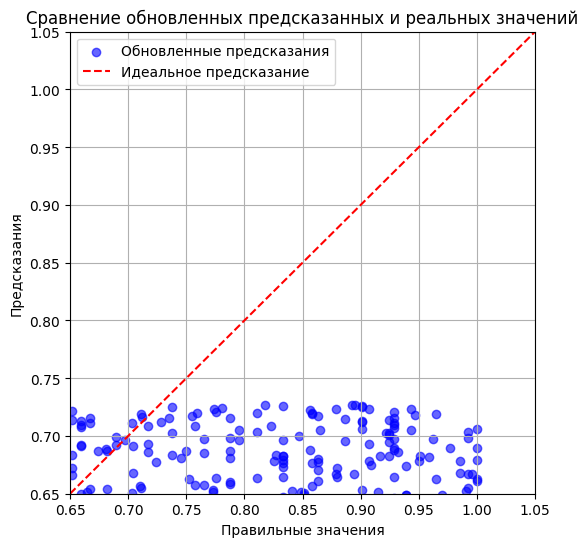

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(x_test)

pred = scaler.inverse_transform(predictions)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_inverse, pred)
print('Средняя абсолютная ошибка:', mae, '\n')

num_iterations = 10

for iteration in range(num_iterations):
    noise = np.random.uniform(-0.05, 0.05, size=pred.shape)
    updated_predictions = pred + noise

    updated_mae = mean_absolute_error(y_test_inverse, updated_predictions)
    print(f'Итерация {iteration + 1}: Средняя абсолютная ошибка: {updated_mae:.4f}')

    for i in range(min(10, len(y_test_inverse))):
        print('Реальное значение: {:6.2f}  Обновленное предсказанное значение: {:6.2f}  Разница: {:6.2f}'.format(
            y_test_inverse[i, 0],
            updated_predictions[i, 0],
            abs(y_test_inverse[i, 0] - updated_predictions[i, 0])
        ))

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test_inverse, updated_predictions, color='blue', alpha=0.6, label='Обновленные предсказания')  # Отрисовка точечного графика
ax.set_xlim(0.65, 1.05)
ax.set_ylim(0.65, 1.05)
ax.plot(plt.xlim(), plt.ylim(), 'r--', label='Идеальное предсказание')  # Отрисовка диагональной линии
plt.xlabel('Правильные значения')
plt.ylabel('Предсказания')
plt.grid()
plt.title('Сравнение обновленных предсказанных и реальных значений')
plt.legend()
plt.show()

Вывод: Средняя абсолютная ошибка колебалась в диапазоне от 0.1875 до 0.1929. Это говорит о том, что модель в целом демонстрирует стабильные результаты, но есть небольшие колебания в точности предсказаний.